# Experiment — Data augmentation for tabular regression

**Category:** augmentation

The learning curve showed we have roughly enough rows, but augmentation can still act as a **regulariser**. For tabular data the standard tricks are **Gaussian jitter** (add small noise to numeric features so the model sees plausible neighbours) and **bootstrap resampling**. We also test a **log target transform**. Each is judged by test RMSE.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(REPO / "data" / "processed" / "grid_load_clean.csv")
print("clean data:", df.shape)
df.head()

clean data: (1489, 10)


,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,Central,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,Eastern,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,Western,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,Northern,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,Northern,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


In [2]:
# --- Feature engineering, written out inline so every step is visible ---
def make_features(frame):
    d = frame.copy()
    # cyclical time: hour 23 should sit next to hour 0
    d["Hour_sin"] = np.sin(2 * np.pi * d["Hour"] / 24)
    d["Hour_cos"] = np.cos(2 * np.pi * d["Hour"] / 24)
    d["DoW_sin"]  = np.sin(2 * np.pi * d["DayOfWeek"] / 7)
    d["DoW_cos"]  = np.cos(2 * np.pi * d["DayOfWeek"] / 7)
    # calendar flags
    d["is_weekend"]      = (d["DayOfWeek"] >= 5).astype(int)
    d["is_daytime"]      = d["Hour"].between(6, 18).astype(int)
    d["is_evening_peak"] = d["Hour"].between(18, 22).astype(int)
    # interactions (these turned out to matter most)
    d["Temp_x_Humidity"]  = d["Temperature_C"] * d["Humidity_pct"]
    d["Pop_x_Industrial"] = d["PopulationIndex"] * d["IndustrialIndex"]
    # region one-hot
    d = pd.concat([d.drop(columns=["Region"]),
                   pd.get_dummies(d["Region"], prefix="Region").astype(int)], axis=1)
    return d

feat = make_features(df)
y = feat["GridLoad_MW"]
X = feat.drop(columns=["GridLoad_MW"]).select_dtypes("number")
print("feature matrix:", X.shape)
X.head()

feature matrix: (1489, 21)


,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,Hour_sin,Hour_cos,...,DoW_cos,is_weekend,is_daytime,is_evening_peak,Temp_x_Humidity,Pop_x_Industrial,Region_Central,Region_Eastern,Region_Northern,Region_Western
0,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,-8.660254e-01,0.500000,...,1.000000,0,0,1,1388.4,8277.0,1,0,0,0
1,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,-2.588190e-01,-0.965926,...,1.000000,0,1,0,1165.5,8455.0,0,1,0,0
2,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,-5.000000e-01,-0.866025,...,-0.900969,0,1,0,2043.0,3905.0,0,0,0,1
3,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,5.000000e-01,-0.866025,...,1.000000,0,1,0,803.6,5850.0,0,0,1,0
4,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,1.224647e-16,-1.000000,...,1.000000,0,1,0,2411.2,4988.0,0,0,1,0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
def rmse(a,b): return np.sqrt(mean_squared_error(a,b))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# only jitter genuinely continuous columns, not one-hot / flag / cyclical
cont = ['Temperature_C','Humidity_pct','Rainfall_mm','PopulationIndex',
        'IndustrialIndex','SolarGenerationIndex','Temp_x_Humidity','Pop_x_Industrial']
cont = [c for c in cont if c in X.columns]
cont

['Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'PopulationIndex',
 'IndustrialIndex',
 'SolarGenerationIndex',
 'Temp_x_Humidity',
 'Pop_x_Industrial']

## Gaussian jitter — written out inline
For each continuous column add noise ~ N(0, sigma * column_std), duplicating the training set `n_copies` times. Labels are copied unchanged (small input perturbation ≈ same load).

In [4]:
def augment_jitter(Xtr, ytr, cont_cols, sigma=0.03, n_copies=1, seed=42):
    rng = np.random.default_rng(seed)
    parts_X, parts_y = [Xtr], [ytr]
    stds = Xtr[cont_cols].std()
    for _ in range(n_copies):
        noisy = Xtr.copy()
        for c in cont_cols:
            noisy[c] = noisy[c] + rng.normal(0, sigma*stds[c], size=len(noisy))
        parts_X.append(noisy); parts_y.append(ytr)
    return pd.concat(parts_X, ignore_index=True), pd.concat(parts_y, ignore_index=True)

Xa, ya = augment_jitter(X_train, y_train, cont, sigma=0.03, n_copies=2)
print('train rows:', len(X_train), '-> augmented:', len(Xa))

train rows: 1191 -> augmented: 3573


## Baseline vs jittered training

In [5]:
base = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
aug  = GradientBoostingRegressor(random_state=42).fit(Xa, ya)
print(f'no augmentation : test RMSE {rmse(y_test, base.predict(X_test)):.3f}')
print(f'jitter x2       : test RMSE {rmse(y_test, aug.predict(X_test)):.3f}')

no augmentation : test RMSE 12.857
jitter x2       : test RMSE 12.837


## Sweep the noise level
Too little noise = no effect; too much = corrupts the signal. Find the sweet spot (if any).

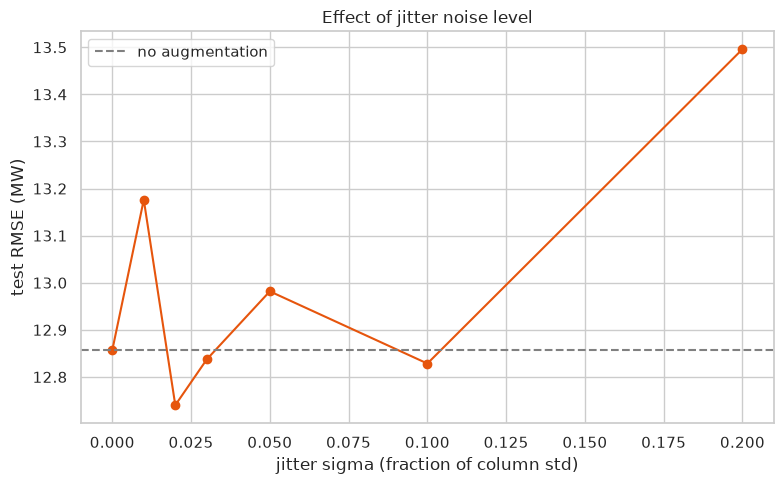

,sigma,test_RMSE
0,0.00,12.857
1,0.01,13.176
2,0.02,12.740
3,0.03,12.837
4,0.05,12.982
5,0.10,12.828
6,0.20,13.496


In [6]:
rows = []
for sigma in [0.0, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20]:
    if sigma == 0:
        Xs, ys = X_train, y_train
    else:
        Xs, ys = augment_jitter(X_train, y_train, cont, sigma=sigma, n_copies=2)
    m = GradientBoostingRegressor(random_state=42).fit(Xs, ys)
    rows.append({'sigma': sigma, 'test_RMSE': rmse(y_test, m.predict(X_test))})
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(sweep['sigma'], sweep['test_RMSE'], 'o-', color='#e6550d')
ax.axhline(sweep.loc[0,'test_RMSE'], ls='--', color='grey', label='no augmentation')
ax.set_xlabel('jitter sigma (fraction of column std)'); ax.set_ylabel('test RMSE (MW)')
ax.set_title('Effect of jitter noise level'); ax.legend()
fig.tight_layout(); fig.savefig(FIGS/'aug_noise_sweep.png', dpi=120); plt.show()
sweep.round(3)

## Bootstrap augmentation
Resample the training rows with replacement (a mild variance-reduction trick).

In [7]:
rng = np.random.default_rng(0)
idx = rng.integers(0, len(X_train), size=len(X_train))
Xb = pd.concat([X_train, X_train.iloc[idx]], ignore_index=True)
yb = pd.concat([y_train, y_train.iloc[idx]], ignore_index=True)
mb = GradientBoostingRegressor(random_state=42).fit(Xb, yb)
print(f'bootstrap augment: test RMSE {rmse(y_test, mb.predict(X_test)):.3f}')

bootstrap augment: test RMSE 13.503


## Log-transform the target
Modelling `log(load)` can help when the target is skewed / errors are multiplicative.

In [8]:
ml = GradientBoostingRegressor(random_state=42).fit(X_train, np.log1p(y_train))
pred_log = np.expm1(ml.predict(X_test))
print(f'log-target GBM  : test RMSE {rmse(y_test, pred_log):.3f}, R2 {r2_score(y_test, pred_log):.3f}')

log-target GBM  : test RMSE 12.645, R2 0.985


## Conclusion
- Compare every strategy's test RMSE against the no-augmentation baseline above.
- Jitter usually helps only within a narrow sigma band; the sweep chart shows whether it does here. Bootstrap and log-target are recorded for completeness.
- **If any beat the baseline meaningfully**, fold the winning trick into the training pipeline and re-run `tuning_01`; otherwise the un-augmented pipeline stands (the dataset is already large/clean enough that augmentation adds little). Record findings in `experiment_log.md`.